Summary: in this notebook we look at how to extract and plot data like absorption fraction and energy injected, which is quite important in many cases.

Import modules needed

In [3]:
import sdf_xarray as sdfxr
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

We will use the test_ang_spectrum simulation as an example.

In [4]:
ds= sdfxr.open_mfdataset("/home/pnd531/Desktop/Project_EPOCH/dev_test/test_ang_spectrum/sdf_files/*.sdf")

To start with, let's plot the laser absorption fraction against time.

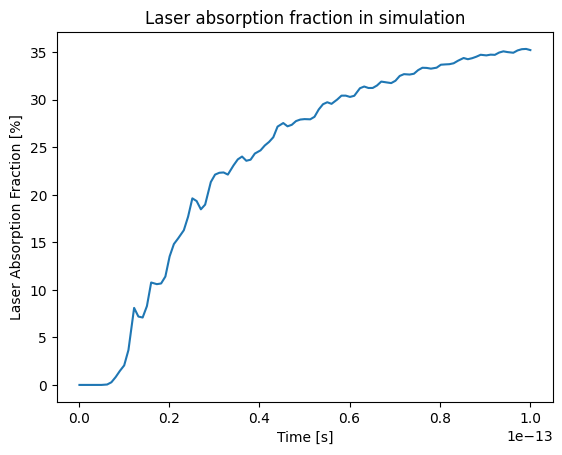

In [5]:
ds["Laser_Absorption_Fraction_in_Simulation"] = (
   (ds["Total_Particle_Energy_in_Simulation"] - ds["Total_Particle_Energy_in_Simulation"][0])
   / ds["Absorption_Total_Laser_Energy_Injected"]
) * 100

# We can also manipulate the units and other attributes
ds["Laser_Absorption_Fraction_in_Simulation"].attrs["units"] = "%"
ds["Laser_Absorption_Fraction_in_Simulation"].attrs["long_name"] = "Laser Absorption Fraction"

ds["Laser_Absorption_Fraction_in_Simulation"].plot()
plt.title("Laser absorption fraction in simulation")
plt.show()

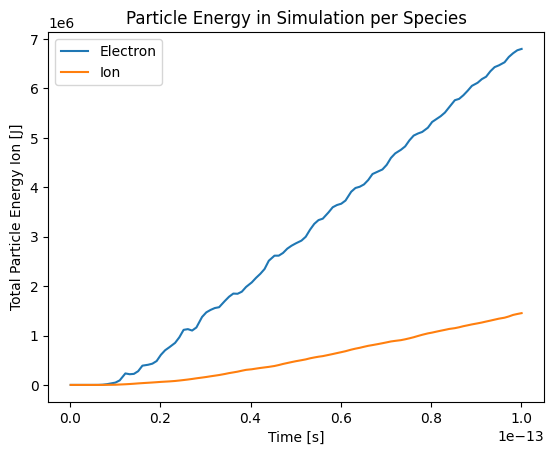

In [7]:
ds["Total_Particle_Energy_Electron"].plot(label="Electron")
ds["Total_Particle_Energy_Ion"].plot(label="Ion")
plt.title("Particle Energy in Simulation per Species")
plt.legend()
plt.show()

One important note: EPOCH 2D assumes a default length scale in z direction (1m). This does not affect the simulation (we have translational invariance along z). However, this affects variables like total laser energy injected as EPOCH takes the third dimention (1m) into account. This makes the values abnormally large, but this isn't an indicator that the simulation is wrong. 
To obtain an estimate, multiply by a scale length divided by 1m: i.e. true_value = value* (scale_length/1m) where the scale_length is often set to me the width of the laser beam (along y axis) -- a few microns in many cases.
Nevertheless, this does not affect fractions like above.

In [8]:
print(f"Total laser energy injected: {ds["Absorption_Total_Laser_Energy_Injected"][-1].values:.1e} J")
print(f"Total particle energy absorbed: {ds["Total_Particle_Energy_in_Simulation"][-1].values:.1e} J")
print(f"The laser absorption fraction: {ds["Laser_Absorption_Fraction_in_Simulation"][-1].values:.1f} %")

Total laser energy injected: 2.5e+07 J
Total particle energy absorbed: 8.8e+06 J
The laser absorption fraction: 35.2 %


In [9]:
scale_length = 5e-6
print(f"Total laser energy injected: {scale_length * ds["Absorption_Total_Laser_Energy_Injected"][-1].values:.1e} J")
print(f"Total particle energy absorbed: {scale_length * ds["Total_Particle_Energy_in_Simulation"][-1].values:.1e} J")
print(f"The laser absorption fraction: {scale_length * ds["Laser_Absorption_Fraction_in_Simulation"][-1].values:.1f} %")

Total laser energy injected: 1.3e+02 J
Total particle energy absorbed: 4.4e+01 J
The laser absorption fraction: 0.0 %
